# OSRM Validation

This file is for validating the usage of OSRM for route finding by comparing the driving time estimation by OSRM with real time cost.

In [1]:
# import relevant packages
import numpy as np
import pandas as pd

from pyproj import CRS, Transformer
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Server Query with OSRM

Then another way is tried here. An OSRM server is deployed locally for navigation based on OSM map in England. The following code uses this service to calculate the driving time.

In [2]:
# create a transformer to convert the coordinates from EPSG:27700 to EPSG:4326
crs_trans = Transformer.from_crs(CRS.from_epsg(27700), CRS.from_epsg(4326), always_xy=True)


In [3]:
%%script true
# read the station coordinates and transform them
station_raw = pd.read_csv('SimEnv/Data/station.csv', usecols=['Easting', 'Northing'])

station_coords = np.zeros((station_raw.shape[0], 2), dtype=np.float64)  # an array for the output coordinates
for i, row in x.iterrows():
    station_coords[i] = crs_trans.transform(row.iloc[0], row.iloc[1])
# station_coords = np.concatenate([station_coords[0].T, station_coords[1].T], axis=1, dtype=np.float64)

# save the result
np.savetxt('Data/temp/station_coords.txt', station_coords, fmt='%f', delimiter=',', encoding='utf-8')


In [4]:
%%script true
# This cell takes around 10 mins.
# read the event locations and transform them to EPSG:4326
event_raw = pd.read_csv('Data/wmfs_incidents_cleaned.csv', usecols=[0, 9, 10])
# print(event_raw.head())

event_coords = event_raw.copy()  # keep the first column of IDs
for i, row in event_raw.iterrows():
    if i % 10000 == 0:
        print(f'Processing row {i} of {event_raw.shape[0]}')
    event_coords.iloc[i, [1, 2]] = crs_trans.transform(row.iloc[1], row.iloc[2])
    # if i > 10000:
    #     break


# save the result
event_coords.to_csv('Data/temp/event_coords.csv', sep=',', index=False)

In [4]:
# load the station and event data
station = np.loadtxt('Data/temp/station_coords.txt', dtype=np.float64, delimiter=',')
event = np.loadtxt('Data/temp/event_coords.csv', dtype=np.float64, delimiter=',', skiprows=1, usecols=[1, 2])

print(len(station))


40


In [5]:
# define a function to parse the coordinates to required formats (normal requests in OSRM)
def parser(a : np.ndarray, b: np.ndarray) -> str:
    return str(a[0]) + ',' + str(a[1]) + ';' + str(b[0]) + ',' + str(b[1])

print(parser(station[0], event[0]))


-1.924575,52.623102;-2.051166314,52.53843293


In [6]:
# try to query the api
# define the parameters
kv = {
    'steps': 'true'
}

full_url = 'http://127.0.0.1:5010/route/v1/driving/' + parser(station[5], event[2])
print(" Final URL:", full_url)

response = requests.get(full_url, params=kv)
# try request detailed route
# response = requests.get('http://127.0.0.1:5010/route/v1/driving/' + parser(station[0], event[0]), params=kv)

response.json()

 Final URL: http://127.0.0.1:5010/route/v1/driving/-1.459379,52.404991;-1.79445107,52.55912201


{'code': 'Ok',
 'routes': [{'geometry': 'cjz~Hf_|G}iA~Fiv@clBkiAkfAm[~~Aa|BxwG{YhgBu]h{FpW|uG}Bn_FeQrlEu`@hhBeY`{C}`@lr@ajCpoAwpC~]o{@oQew@jR}YraAgPtL`\\~oAeFzqBmb@jhAbApj@',
   'legs': [{'steps': [{'intersections': [{'out': 0,
         'entry': [True],
         'bearings': [9],
         'location': [-1.459243, 52.404983]}],
       'driving_side': 'right',
       'geometry': 'cjz~Hf_|Gy@MWE',
       'mode': 'driving',
       'duration': 10.3,
       'maneuver': {'bearing_after': 9,
        'type': 'depart',
        'modifier': 'left',
        'bearing_before': 0,
        'location': [-1.459243, 52.404983]},
       'weight': 10.3,
       'distance': 46.1,
       'name': 'Mayflower Drive'},
      {'intersections': [{'out': 2,
         'location': [-1.459137, 52.405392],
         'bearings': [105, 195, 285],
         'entry': [True, False, True],
         'in': 1}],
       'driving_side': 'right',
       'geometry': 'ulz~Hr~{GGXGd@CREX',
       'mode': 'driving',
       'duration': 10.9,


In [16]:
def table_parser(loc : np.ndarray, sources_list : list):
    out1, sou, des = '', '', ''
    for i in range(loc.shape[0]):
        out1 += str(loc[i, 0]) + ',' + str(loc[i, 1]) + ';'
        if i in sources_list:
            sou += str(i) + ';'
        else:
            des += str(i) + ';'
    out1 = out1[:-1]
    out2 = {'sources': sou[:-1], 'destinations': des[:-1]}
    return out1, out2

a, b = table_parser(station[:3], [0])
print(a)
print(b)

-1.924575,52.623102;-1.893646,52.505248;-1.712608,52.453947
{'sources': '0', 'destinations': '1;2'}


In [17]:
# this cell takes around 2 mins 26 senconds
# run all stations and part of events at a time

import numpy as np
import requests
from tqdm import tqdm  


min_times = []
sample_size = 200 # the number of events to handle

for i in tqdm(range(0, event.shape[0], sample_size)):
    # the event index of the current batch
    event_list = [j for j in range(i, min(i + sample_size, event.shape[0]))]
    
    # combine the coordinate list as the type what OSRM need（station + event_batch）
    temp = np.concatenate([station, event[event_list]], axis=0)

    # URL
    locs, kv = table_parser(temp, [j for j in range(station.shape[0])])  # station 是 source

    try:
        response = requests.get('http://127.0.0.1:5010/table/v1/driving/' + locs, params=kv)
        durations = np.array(response.json()['durations']).T  # shape: (num_events, num_stations)
        batch_min_times = np.min(durations, axis=1)
        min_times.append(batch_min_times)
    except Exception as e:
        print(f" Error in batch {i}: {e}")

min_times_array = np.concatenate(min_times)

min_times_array



100%|██████████| 2074/2074 [02:26<00:00, 14.18it/s]


array([137.4,  79. , 455.7, ..., 433.3, 181.9, 279.2])

In [ ]:
# save as npy
np.save('Data/temp/min_osrm_time.npy', min_times_array)
print(" Done. Shape:", min_times_array.shape)

In [ ]:
%%script true
# this cell takes around 15-20 minutes
# run all stations and part of events at a time

out = np.zeros((0, station.shape[0]), dtype=np.int32)

sample_size = 200  # the number of events to handle

for i in range(0, event.shape[0], sample_size):
    if i % 1000 == 0:
        print(i)
    # prepare event list
    event_list = [j for j in range(i, min(i + sample_size, event.shape[0]))]
    temp = np.concatenate([station, event[event_list]], axis=0)
    locs, kv = table_parser(temp, [j for j in range(station.shape[0])])

    # try to request driving time
    response = requests.get('http://127.0.0.1:5010/table/v1/car/' + locs, params=kv)
    out1 = response.json()['durations']
    out1 = np.array(out1).T  # this is the driving time cost from all stations to a fire event
    out = np.concatenate([out, out1])
    # if i > 1000:
    #     break

# save the result
np.savetxt('/Users/zhaoyuxin/Repos/fire_station_optimisation_ga/utils/Data/temp/drv_time_osrm_raw1.csv', out, fmt='%d', delimiter=',', encoding='utf-8')


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
155000
156000
157000
158000


In [12]:
# load and polish the result table
table = np.loadtxt('Data/temp/drv_time_osrm_raw1.csv', dtype=np.int32, delimiter=',', encoding='utf-8')
# add another column of the nearest station IDs for each event site as the first column
nearest_station_ids = np.argmin(table, axis=1)
min_time = np.min(table, axis=1)

# Build a pandas Dataframe from the np.array data
output = pd.DataFrame(data=table, columns=[f'Station {i}' for i in range(station.shape[0])])

event2 = pd.read_csv('Data/temp/event_coords.csv')  # load event data from the csv file again
station2 = pd.read_csv('Data/station_locations.csv')

print(station2.index)

# Four new columns are added, i.e. the event IDs, the nearest station IDs and names, and the corresponding driving time
output.insert(0, 'Incident_Number', event2.loc[:, 'Incident_Number'])
output.insert(1, 'Nearest_Station_ID', nearest_station_ids)
output.insert(2, 'Nearest_Station_Name', None)
for i in range(output.shape[0]):
    output.iloc[i, 2] = station2.loc[nearest_station_ids[i], 'Station name']
output.insert(3, 'Min_Driving_time', min_time)
output.head()

# save the result
output.to_csv('Data/temp/drv_time_osrm.csv', index=False, encoding='utf-8')

RangeIndex(start=0, stop=40, step=1)


## 2. Validation

The estimated driving time is compared with the actual driving time in the mobilisation data.

In [11]:
# load the mobilisation data
mob = pd.read_csv('Data/wmfs_mobilisations_cleaned.csv', usecols=['Incident_Number', 'callsign_station', 'driving_seconds'])
mob.head(10)

,Incident_Number,callsign_station,driving_seconds
0,2,Wednesbury,357
1,3,Fallings Park,137
2,4,Sutton Coldfield,243
3,5,Bloxwich,298
4,6,Foleshill,143
5,6,Foleshill,142
6,7,Stourbridge,290
7,7,Brierley Hill,409
8,8,Wednesbury,246
9,9,Sutton Coldfield,415


In [12]:
# convert the station names to IDs
station2 = pd.read_csv('SimEnv/Data/station_locations.csv', usecols=['Station name'])
station2.head()


,Station name
0,Aldridge
1,Aston
2,Bickenhill
3,Billesley
4,Bilston


In [13]:
# check the unique station names in mob
temp = mob['callsign_station'].unique()
temp.sort()
for i in range(temp.shape[0]):
    print(temp[i])

# mob['station_id'] = mob['callsign_station'].apply(lambda x: station2[station2['Station name'] == x].index[0])
# mob.head()

Aldridge
Aston
Bickenhill
Billesley
Bilston
Binley
Bloxwich
Bournbrook
Brierley Hill
Canley
Coventry
Dudley
Erdington
Fallings Park
Foleshill
Haden Cross
Handsworth
Hay Mills
Highgate
Kings Norton
Ladywood
Northfield
Oldbury
Perry Barr
Sheldon
Smethwick
Solihull
Stourbridge
Sutton Coldfield
Tettenhall
Tipton
Walsall
Ward End
Wednesbury
West Bromwich
Willenhall
Wolverhampton
Woodgate Valley


In [14]:
# Mapping from station names to IDs. If the station name is not in the station2, we will use nan value.
mapping = {}

for i in range(temp.shape[0]):
    if temp[i] in station2['Station name'].values:
        mapping[temp[i]] = station2[station2['Station name'] == temp[i]].index[0]
    else:
        mapping[temp[i]] = np.nan

print(mapping)

{'Aldridge': np.int64(0), 'Aston': np.int64(1), 'Bickenhill': np.int64(2), 'Billesley': np.int64(3), 'Bilston': np.int64(4), 'Binley': np.int64(5), 'Bloxwich': np.int64(6), 'Bournbrook': np.int64(7), 'Brierley Hill': np.int64(8), 'Canley': np.int64(9), 'Coventry': np.int64(10), 'Dudley': np.int64(12), 'Erdington': np.int64(13), 'Fallings Park': np.int64(14), 'Foleshill': np.int64(15), 'Haden Cross': np.int64(16), 'Handsworth': np.int64(18), 'Hay Mills': np.int64(19), 'Highgate': np.int64(20), 'Kings Norton': np.int64(21), 'Ladywood': np.int64(22), 'Northfield': np.int64(23), 'Oldbury': np.int64(24), 'Perry Barr': np.int64(25), 'Sheldon': np.int64(26), 'Smethwick': np.int64(27), 'Solihull': np.int64(28), 'Stourbridge': np.int64(29), 'Sutton Coldfield': np.int64(30), 'Tettenhall': np.int64(31), 'Tipton': np.int64(32), 'Walsall': np.int64(33), 'Ward End': np.int64(34), 'Wednesbury': np.int64(35), 'West Bromwich': np.int64(36), 'Willenhall': np.int64(37), 'Wolverhampton': np.int64(38), 'Wo

In [15]:
# Add a new column called station_ids and use the mapping to convert the station names to IDs
mob2 = mob.copy()
mob2.insert(2, 'Station_ID', mob2['callsign_station'].map(mapping), allow_duplicates=False)

# Check the count of nan values and remove them
print(mob2['Station_ID'].isna().sum())
mob2 = mob2.dropna(subset=['Station_ID'])

# Convert the Station_ID to integer type
mob2['Station_ID'] = mob2['Station_ID'].astype(int)

mob2.head()

0


,Incident_Number,callsign_station,Station_ID,driving_seconds
0,2,Wednesbury,35,357
1,3,Fallings Park,14,137
2,4,Sutton Coldfield,30,243
3,5,Bloxwich,6,298
4,6,Foleshill,15,143


In [16]:
# load the driving time estimation by OSRM and add the corresponding time to mob2
cols = [i for i in range(4, 4 + station.shape[0])]
cols.insert(0, 0)  # add the first column
osrm = pd.read_csv('Data/temp/drv_time_osrm.csv', usecols=cols)
osrm.head()

,Incident_Number,Station 0,Station 1,Station 2,Station 3,Station 4,Station 5,Station 6,Station 7,Station 8,...,Station 30,Station 31,Station 32,Station 33,Station 34,Station 35,Station 36,Station 37,Station 38,Station 39
0,2,1480,1120,1750,1675,470,2707,1156,1446,857,...,1555,1221,135,795,1426,301,497,739,860,1097
1,3,1533,1455,2013,2179,628,2970,1051,1984,1320,...,1905,635,1042,889,1688,865,1152,672,424,1760
2,4,1413,1007,1195,1731,1781,2124,1910,1595,2286,...,458,2449,1764,1567,931,1578,1452,1680,2161,1883
3,5,471,1484,1884,2207,1133,2812,405,2072,1969,...,1339,1581,1389,587,1717,1116,1302,759,1346,1868
4,6,2267,1554,1098,2163,2326,666,2464,2141,2832,...,1675,2994,2309,2112,1543,2124,1998,2226,2706,2430


In [17]:
# Add a new column in mob2 called driving_osrm
mob2['driving_osrm'] = 0

In [18]:
%%script true
# this cell takes around 5 mins.
# fill in the driving_osrm column by looking up the driving time from osrm.
# Ways to look up: Incident_Number as row idetifier, Station_ID as column identifier
for i, row in mob2.iterrows():
    if i % 1000 == 0:
        print(f'Processing row {i} of {mob2.shape[0]}')
    # find the row in osrm by Incident_Number
    mask = osrm['Incident_Number'] == row['Incident_Number']
    if mask.any():
        # find the column in osrm by Station_ID
        col = row['Station_ID']
        mob2.at[i, 'driving_osrm'] = osrm.loc[mask, f'Station {col}'].values[0]
    else:
        print(f'Incident_Number {row["Incident_Number"]} not found in OSRM data.')

In [19]:
%%script true
# save the result
mob2.to_csv('Data/temp/osrm_validation.csv', index=False, encoding='utf-8')

In [20]:
# load the result
mob2 = pd.read_csv('Data/temp/osrm_validation.csv', encoding='utf-8')
mob2.head()

,Incident_Number,callsign_station,Station_ID,driving_seconds,driving_osrm
0,2,Wednesbury,35,357,301
1,3,Fallings Park,14,137,79
2,4,Sutton Coldfield,30,243,458
3,5,Bloxwich,6,298,405
4,6,Foleshill,15,143,318


In [21]:
# remove the rows with driving_osrm = 0
mob3 = mob2.copy()
mob3 = mob3[mob3['driving_seconds'] > 0]

# calculate the ratio of the estimated driving time by OSRM and the actual driving time
mob3['driving_ratio'] = mob3['driving_osrm'] / mob3['driving_seconds']
mob3.head()

,Incident_Number,callsign_station,Station_ID,driving_seconds,driving_osrm,driving_ratio
0,2,Wednesbury,35,357,301,0.843137
1,3,Fallings Park,14,137,79,0.576642
2,4,Sutton Coldfield,30,243,458,1.884774
3,5,Bloxwich,6,298,405,1.359060
4,6,Foleshill,15,143,318,2.223776


In [22]:
# calcutate the mean and standard deviation of the driving ratio
mean_ratio = mob3['driving_ratio'].mean()
std_ratio = mob3['driving_ratio'].std()
mob3['driving_ratio'].describe()


count    593369.000000
mean          2.958927
std          22.991581
min           0.000000
25%           0.882096
50%           1.157647
75%           1.457859
max        2159.000000
Name: driving_ratio, dtype: float64

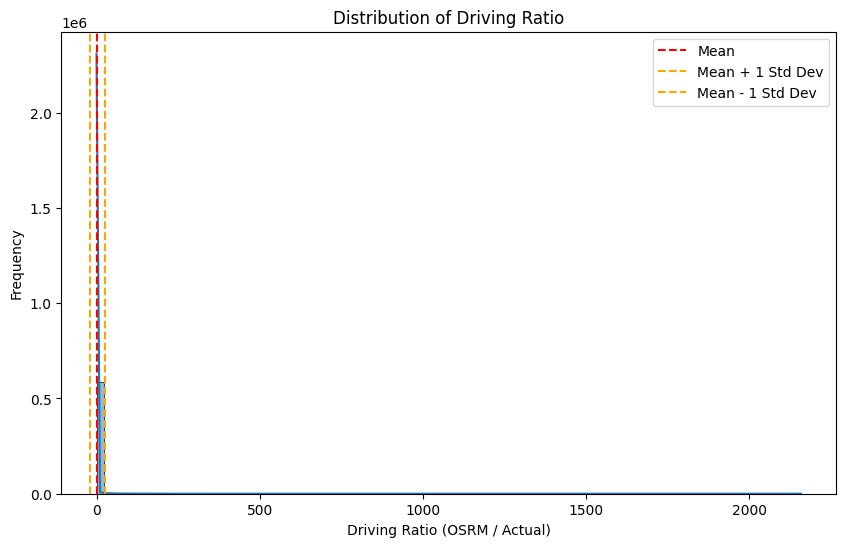

In [23]:
# plot the distribution of the driving ratio
plt.figure(figsize=(10, 6))
sns.histplot(mob3['driving_ratio'], bins=100, kde=True)
plt.title('Distribution of Driving Ratio')
plt.xlabel('Driving Ratio (OSRM / Actual)')
plt.ylabel('Frequency')
plt.axvline(mean_ratio, color='red', linestyle='--', label='Mean')
plt.axvline(mean_ratio + std_ratio, color='orange', linestyle='--', label='Mean + 1 Std Dev')
plt.axvline(mean_ratio - std_ratio, color='orange', linestyle='--', label='Mean - 1 Std Dev')
plt.legend()
plt.show() 


In [24]:
# check the number of records with driving_ratio > a certain threshold
threshold = 10
print(f'Number of records with driving_ratio > {threshold}: {mob3[mob3["driving_ratio"] > threshold].shape[0]} out of {mob3.shape[0]}')

Number of records with driving_ratio > 10: 11338 out of 593369


In [36]:
# try to look at the distribution of the part below the threshold
mob3_part = mob3[mob3["driving_ratio"] <= threshold]
mean_ratio2 = mob3_part['driving_ratio'].mean()
std_ratio2 = mob3_part['driving_ratio'].std()
mob3_part['driving_ratio'].describe()


count    582031.000000
mean          1.248475
std           0.761529
min           0.000000
25%           0.875862
50%           1.147860
75%           1.435616
max          10.000000
Name: driving_ratio, dtype: float64

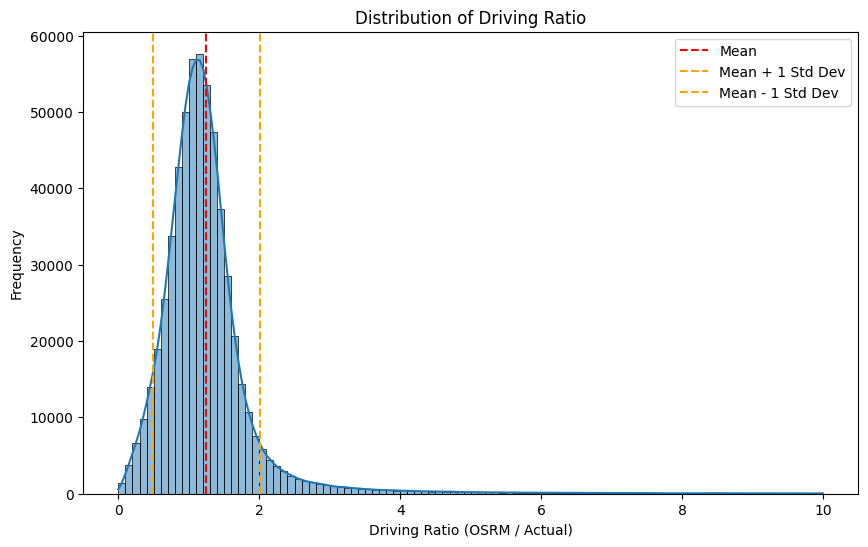

In [37]:
# plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(mob3_part['driving_ratio'], bins=100, kde=True)
plt.title('Distribution of Driving Ratio')
plt.xlabel('Driving Ratio (OSRM / Actual)')
plt.ylabel('Frequency')
plt.axvline(mean_ratio2, color='red', linestyle='--', label='Mean')
plt.axvline(mean_ratio2 + std_ratio2, color='orange', linestyle='--', label='Mean + 1 Std Dev')
plt.axvline(mean_ratio2 - std_ratio2, color='orange', linestyle='--', label='Mean - 1 Std Dev')
plt.legend()
plt.show() 

In [42]:
# calculate the correlation between the estimationa and actual driving time
correlation = mob3['driving_osrm'].corr(mob3['driving_seconds'])
print(f'Correlation between OSRM driving time and actual driving time: {correlation:.2f}')

# calculate the correlation in the part below 10
correlation2 = mob3_part['driving_osrm'].corr(mob3_part['driving_seconds'])
print(f'Correlation between OSRM driving time and actual driving time (driving_ratio <= {threshold}): {correlation2:.2f}')

Correlation between OSRM driving time and actual driving time: 0.44
Correlation between OSRM driving time and actual driving time (driving_ratio <= 10): 0.44


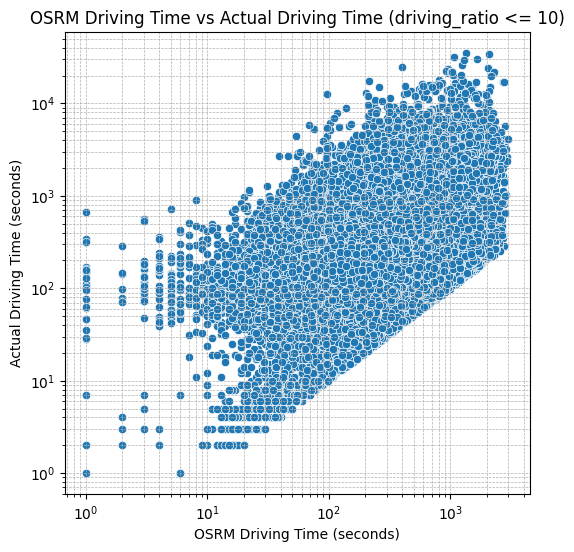

In [46]:
# draw a scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=mob3_part['driving_osrm'], y=mob3_part['driving_seconds'])
plt.title('OSRM Driving Time vs Actual Driving Time (driving_ratio <= 10)')
plt.xlabel('OSRM Driving Time (seconds)')
plt.ylabel('Actual Driving Time (seconds)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In conclusion, OSRM can accurately estimate the driving time in most cases with a little overestimation.